# 🏡 King County Housing EDA for Jennifer Montgomery
**Client Profile**  
Jennifer has a high budget and wants:
- A waterfront, renovated, high-grade house
- In a luxury area
- She plans to resell it within a year

**Goal:**  
Help her identify the best locations and property features to maximize resale value within a short period.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('data/Housing_project.csv')
df.head()

,date,price,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,zipcode,lat,long,grade
0,2014-10-13,221900.0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,98178,47.5112,-122.257,7
1,2014-12-09,538000.0,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,98125,47.7210,-122.319,7
2,2015-02-25,180000.0,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,98028,47.7379,-122.233,6
3,2014-12-09,604000.0,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,98136,47.5208,-122.393,7
4,2015-02-18,510000.0,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,98074,47.6168,-122.045,8


In [3]:
# Dataset info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         21597 non-null  object 
 1   price        21597 non-null  float64
 2   house_id     21597 non-null  int64  
 3   bedrooms     21597 non-null  float64
 4   bathrooms    21597 non-null  float64
 5   sqft_living  21597 non-null  float64
 6   sqft_lot     21597 non-null  float64
 7   floors       21597 non-null  float64
 8   waterfront   19206 non-null  float64
 9   view         21534 non-null  float64
 10  zipcode      21597 non-null  int64  
 11  lat          21597 non-null  float64
 12  long         21597 non-null  float64
 13  grade        21597 non-null  int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 2.3+ MB


,price,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,zipcode,lat,long,grade
count,2.159700e+04,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19206.000000,21534.000000,21597.000000,21597.000000,21597.000000,21597.000000
mean,5.402966e+05,4.580474e+09,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007602,0.233863,98077.951845,47.560093,-122.213983,7.657915
std,3.673681e+05,2.876736e+09,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086858,0.765686,53.513072,0.138552,0.140724,1.173200
min,7.800000e+04,1.000102e+06,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,98001.000000,47.155900,-122.519000,3.000000
25%,3.220000e+05,2.123049e+09,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,98033.000000,47.471100,-122.328000,7.000000
50%,4.500000e+05,3.904930e+09,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,98065.000000,47.571800,-122.231000,7.000000
75%,6.450000e+05,7.308900e+09,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,98118.000000,47.678000,-122.125000,8.000000
max,7.700000e+06,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,98199.000000,47.777600,-121.315000,13.000000


In [4]:
# 🧹 Reusable cleaning function
import pandas as pd

def clean_housing_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df.drop_duplicates(inplace=True)
    df.dropna(subset=['price'], inplace=True)
    if 'bathrooms' in df.columns:
        df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)
    if 'bedrooms' in df.columns:
        df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)
    if 'view' in df.columns:
        df['view'].fillna(0, inplace=True)
    if 'lat' in df.columns and 'long' in df.columns:
        df.dropna(subset=['lat', 'long'], inplace=True)
    df = df[df['price'] < df['price'].quantile(0.99)]
    df = df[df['sqft_living'] < df['sqft_living'].quantile(0.99)]
    if 'zipcode' in df.columns:
        df['zipcode'] = df['zipcode'].astype(str)
    df['year'] = df['date'].dt.year
    return df

In [5]:
# loading the raw data into a DataFrame
df_raw = pd.read_csv('data/Housing_project.csv')

In [6]:
#Apply your cleaning function, right after loading the data
df_clean = clean_housing_data(df_raw)

C:\Users\49176\AppData\Local\Temp\ipykernel_22720\4223718241.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)
C:\Users\49176\AppData\Local\Temp\ipykernel_22720\4223718241.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

TIP: Use df_clean for all further analysis, thus replacing all instances of df or df_raw with df_clean in the rest of the notebook. For example:

<class 'pandas.core.frame.DataFrame'>
Index: 21162 entries, 0 to 21596
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         21162 non-null  datetime64[ns]
 1   price        21162 non-null  float64       
 2   house_id     21162 non-null  int64         
 3   bedrooms     21162 non-null  float64       
 4   bathrooms    21162 non-null  float64       
 5   sqft_living  21162 non-null  float64       
 6   sqft_lot     21162 non-null  float64       
 7   floors       21162 non-null  float64       
 8   waterfront   18817 non-null  float64       
 9   view         21162 non-null  float64       
 10  zipcode      21162 non-null  object        
 11  lat          21162 non-null  float64       
 12  long         21162 non-null  float64       
 13  grade        21162 non-null  int64         
 14  year         21162 non-null  int32         
dtypes: datetime64[ns](1), float64(10), int32(1), int64(2), obj

<Axes: >

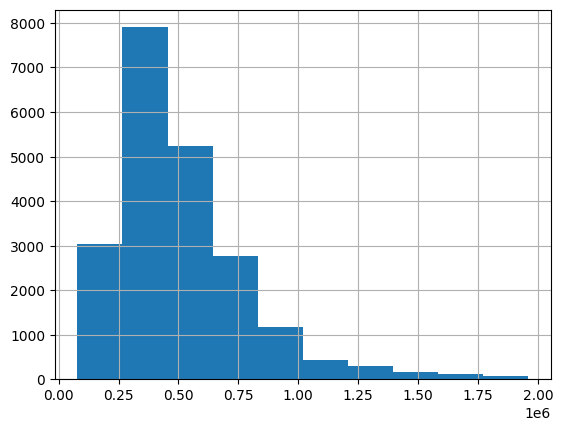

In [7]:

df_clean.info()
df_clean.describe()
df_clean['price'].hist()

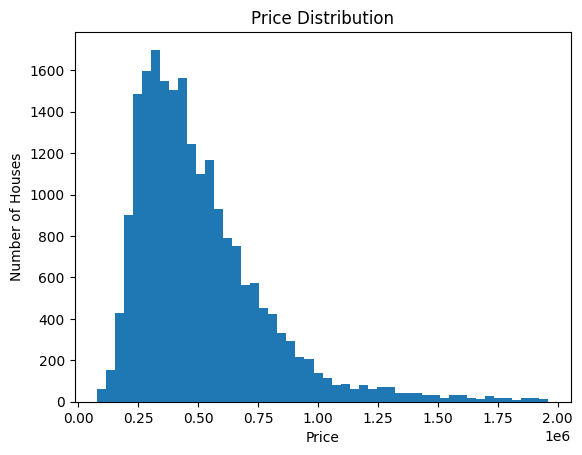

In [8]:
# Price distribution
plt.hist(df_clean['price'], bins=50)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.show()

C:\Users\49176\AppData\Local\Temp\ipykernel_22720\990552206.py:24: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\49176\Dropbox\My PC (DESKTOP-0E15T4G)\Desktop\neuefische GmbH\EDA_Project_E.Ntiriakwa\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


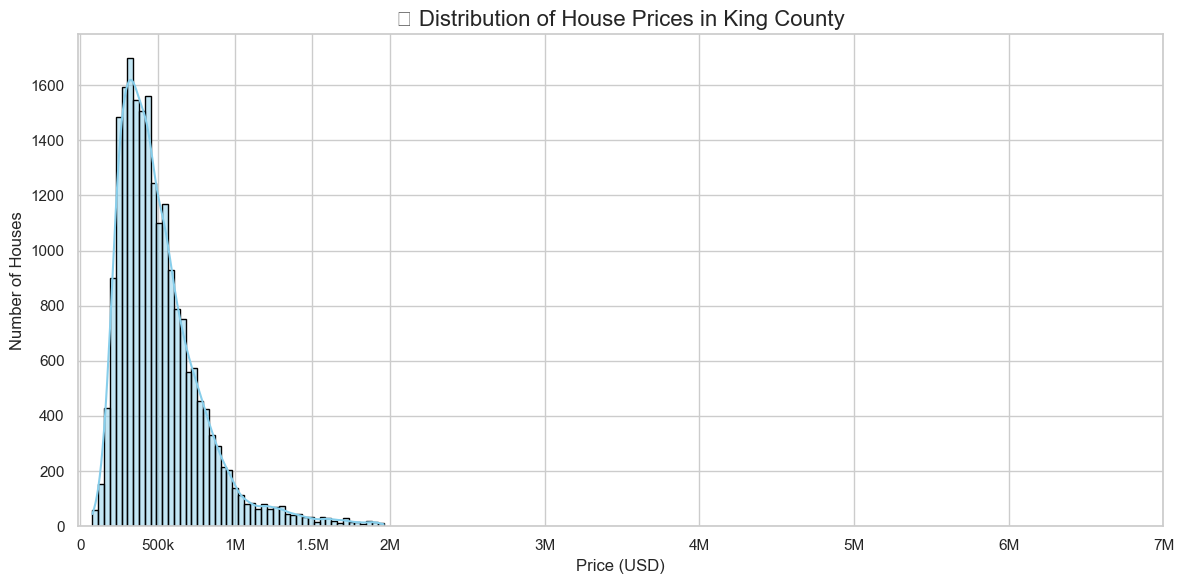

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# Set plot size
plt.figure(figsize=(12, 6))

# Plot with seaborn
sns.histplot(df_clean['price'], bins=50, kde=True, color="skyblue", edgecolor='black')

# Labels and title
plt.title('🏠 Distribution of House Prices in King County', fontsize=16)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)

# Format x-axis to show in millions
plt.xticks(
    ticks=[0, 500000, 1000000, 1500000, 2000000, 3000000, 4000000, 5000000, 6000000, 7000000],
    labels=['0', '500k', '1M', '1.5M', '2M', '3M', '4M', '5M', '6M', '7M']
)

plt.tight_layout()
plt.show()

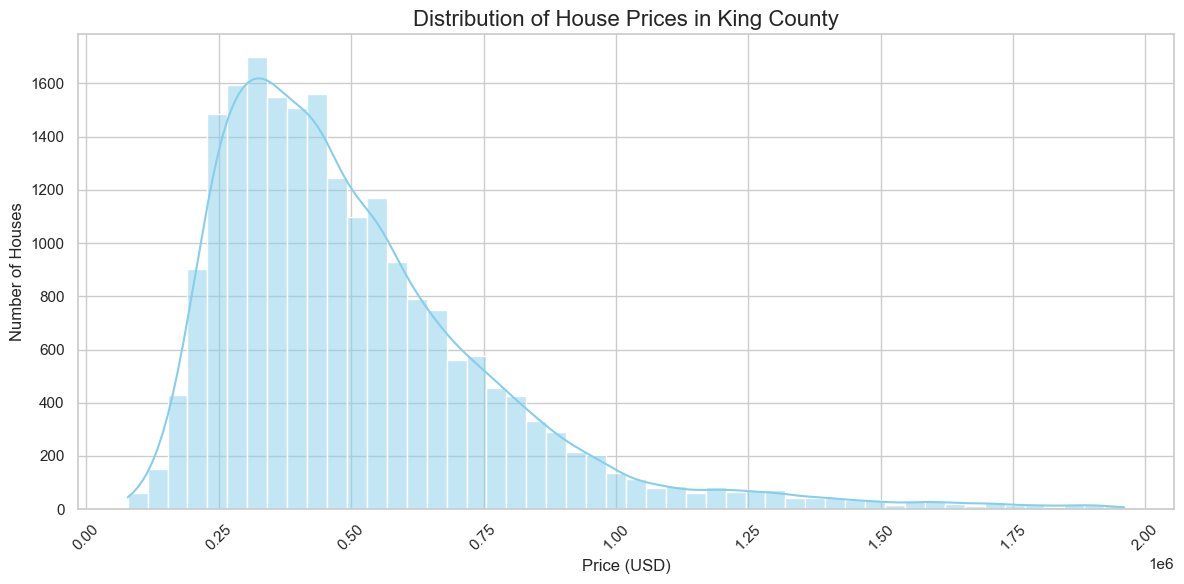

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Create plot
plt.figure(figsize=(12, 6))
sns.histplot(data=df_clean, x='price', bins=50, kde=True, color='skyblue')

# Labels and title
plt.title('Distribution of House Prices in King County', fontsize=16)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Filter luxury homes based on Jennifer's needs
luxury_homes = df_clean[
    (df_clean['price'] > df_clean['price'].quantile(0.90)) &
    (df_clean['waterfront'] == 1) &
    (df_clean['view'] >= 3) &
    (df_clean['sqft_living'] > 2500)
]
luxury_homes.describe()

,date,price,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,lat,long,grade,year
count,37,3.700000e+01,3.700000e+01,37.000000,37.000000,37.000000,37.000000,37.000000,37.0,37.000000,37.000000,37.000000,37.000000,37.000000
mean,2014-11-06 00:38:55.135135232,1.541730e+06,4.650372e+09,3.432432,2.756757,3139.621622,34317.675676,1.702703,1.0,3.864865,47.559835,-122.265811,8.891892,2014.324324
min,2014-06-20 00:00:00,9.500000e+05,6.230590e+08,2.000000,1.750000,2520.000000,3444.000000,1.000000,1.0,3.000000,47.334400,-122.514000,7.000000,2014.000000
25%,2014-07-23 00:00:00,1.310000e+06,2.322029e+09,3.000000,2.500000,2800.000000,11972.000000,1.000000,1.0,4.000000,47.473400,-122.365000,8.000000,2014.000000
50%,2014-11-06 00:00:00,1.600000e+06,4.114602e+09,3.000000,2.750000,3020.000000,18226.000000,2.000000,1.0,4.000000,47.548700,-122.276000,9.000000,2014.000000
75%,2015-02-24 00:00:00,1.850000e+06,7.204200e+09,4.000000,3.000000,3330.000000,26761.000000,2.000000,1.0,4.000000,47.636100,-122.197000,10.000000,2015.000000
max,2015-04-21 00:00:00,1.960000e+06,9.253900e+09,6.000000,4.500000,4380.000000,505166.000000,3.000000,1.0,4.000000,47.772900,-122.060000,12.000000,2015.000000
std,NaN,3.230388e+05,2.639628e+09,0.987155,0.569742,475.771616,81043.823220,0.594646,0.0,0.346583,0.121816,0.116412,1.219831,0.474579


Text(0, 0.5, 'Average Price')

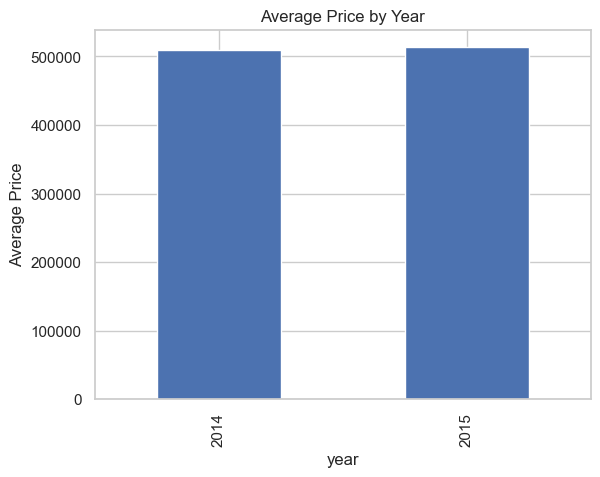

In [12]:
# Add year column and plot average price per year
df_clean['year'] = df_clean['date'].dt.year
df_clean.groupby('year')['price'].mean().plot(kind='bar')
plt.title('Average Price by Year')
plt.ylabel('Average Price')

C:\Users\49176\AppData\Local\Temp\ipykernel_22720\2149477521.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_per_year, x='year', y='price', palette='Blues_d')
C:\Users\49176\AppData\Local\Temp\ipykernel_22720\2149477521.py:28: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\49176\AppData\Local\Temp\ipykernel_22720\2149477521.py:29: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  plt.savefig("avg_price_by_year.png", dpi=300)
c:\Users\49176\Dropbox\My PC (DESKTOP-0E15T4G)\Desktop\neuefische GmbH\EDA_Project_E.Ntiriakwa\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


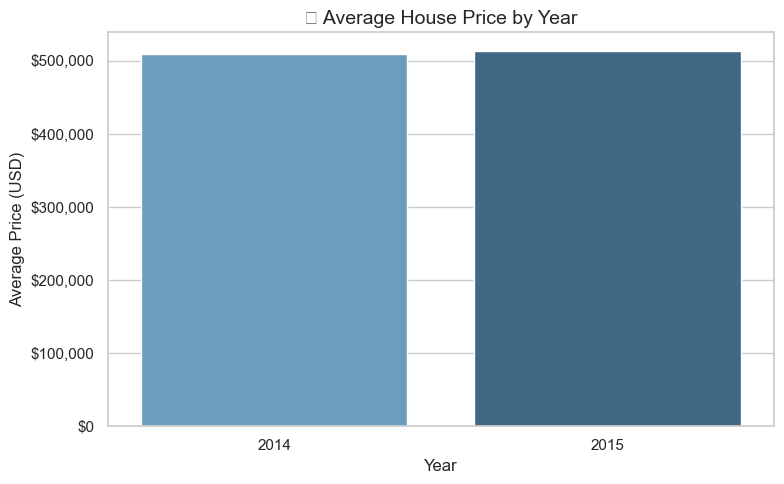

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract year from date if not already done
df_clean['year'] = pd.to_datetime(df_clean['date']).dt.year

# Group and calculate average price per year
avg_price_per_year = df_clean.groupby('year')['price'].mean().reset_index()

# Set plot style
sns.set(style="whitegrid")

# Create plot
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_price_per_year, x='year', y='price', palette='Blues_d')

# Title and labels
plt.title('🏠 Average House Price by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price (USD)', fontsize=12)
plt.xticks(rotation=0)

# Format y-axis in dollars
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Save as PNG (optional)
plt.tight_layout()
plt.savefig("avg_price_by_year.png", dpi=300)
plt.show()

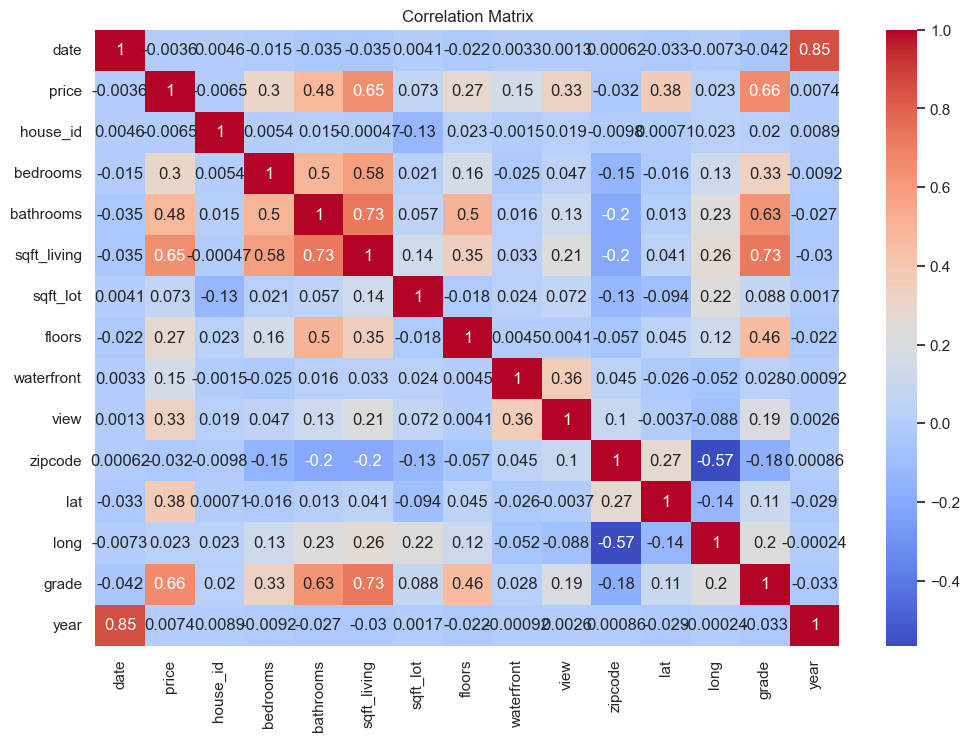

In [14]:
# 🧹 Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

📊 Interpretation of the Correlation Matrix
Price is most strongly correlated with:

sqft_living (0.65) → larger homes tend to cost more.

bathrooms (0.48) and bedrooms (0.3) also show moderate correlation with price.

sqft_living and bathrooms are strongly correlated (0.73), suggesting larger homes have more bathrooms.

Waterfront (0.15) and view (0.38) have weak-to-moderate positive correlation with price.

Year has no meaningful correlation with price, despite being strongly tied to the date column (0.85), which is expected.

zipcode has low or negative correlations with most variables, indicating location codes are not linearly related to other features.

No variables show a strong negative correlation with price.

### 🔬 Hypotheses
1. Waterfront homes with higher view scores sell for significantly more.
2. Homes with larger living space and higher grade give better short-term resale potential.
3. Certain zip codes have a concentration of top 10% homes that meet Jennifer’s needs.

In [15]:
# Test hypothesis 1 and 2
print(df_clean.groupby('waterfront')['price'].mean())
print(df_clean.groupby('view')['price'].mean())
print(df_clean[['sqft_living', 'price']].corr())

waterfront
0.0    5.079568e+05
1.0    1.088606e+06
Name: price, dtype: float64
view
0.0    4.837211e+05
1.0    7.196603e+05
2.0    7.092476e+05
3.0    8.372587e+05
4.0    1.042144e+06
Name: price, dtype: float64
             sqft_living     price
sqft_living     1.000000  0.650933
price           0.650933  1.000000


In [16]:
# Hypothesis 3: Top 10% homes by price
top_10_percent = df_clean[df_clean['price'] > df_clean['price'].quantile(0.90)]
top_zipcodes = top_10_percent['house_id'].value_counts().head(10)
top_zipcodes

house_id
4139420590    2
9809000020    2
3262300940    2
4139480200    2
7856400240    2
7701960990    2
5332200530    2
5536100020    2
7856400300    2
9822700295    1
Name: count, dtype: int64

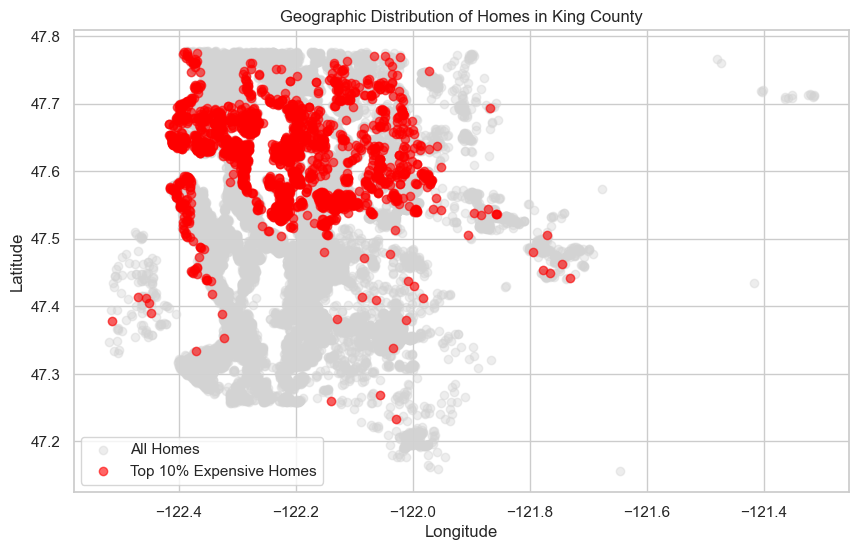

In [17]:
import matplotlib.pyplot as plt

# Create top 10% price filter
top_10_threshold = df_clean['price'].quantile(0.90)
top_10 = df_clean[df_clean['price'] > top_10_threshold]

# Set up plot
plt.figure(figsize=(10, 6))

# Plot all homes
plt.scatter(df_clean['long'], df_clean['lat'], c='lightgrey', alpha=0.4, label='All Homes')

# Highlight top 10% homes
plt.scatter(top_10['long'], top_10['lat'], c='red', alpha=0.6, label='Top 10% Expensive Homes')

# Labels
plt.title('Geographic Distribution of Homes in King County')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Visualize the geographic distribution of homes in King County using Plotly
# Interactive map using Plotly
# Here we get zoom, pan, and tooltips.
import plotly.express as px

# Create top 10% price filter
top_10_threshold = df_clean['price'].quantile(0.90)
top_10 = df_clean[df_clean['price'] > top_10_threshold]

# Plotly scatter map
fig = px.scatter_mapbox(
    df_clean,
    lat='lat',
    lon='long',
    color_discrete_sequence=['lightgrey'],
    opacity=0.3,
    zoom=9,
    height=600,
    title='Homes in King County',
    hover_data=['price']
)

# Add top 10% homes in red
fig.add_trace(px.scatter_mapbox(
    top_10,
    lat='lat',
    lon='long',
    color_discrete_sequence=['red'],
    opacity=0.6,
    hover_data=['price']
).data[0])

# Map settings
fig.update_layout(
    mapbox_style='carto-positron',
    mapbox_zoom=9,
    mapbox_center={"lat": df_clean['lat'].mean(), "lon": df_clean['long'].mean()},
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()

C:\Users\49176\AppData\Local\Temp\ipykernel_22720\2636374439.py:11: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(
C:\Users\49176\AppData\Local\Temp\ipykernel_22720\2636374439.py:24: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [19]:
import plotly.express as px

# Create top 10% price filter
top_10_threshold = df_clean['price'].quantile(0.90)
top_10 = df_clean[df_clean['price'] > top_10_threshold]

# Main scatter map for all homes, colored by price
fig = px.scatter_mapbox(
    df_clean,
    lat='lat',
    lon='long',
    color='price',  # color scale by price
    size_max=10,
    opacity=0.3,
    zoom=9,
    height=600,
    title='Homes in King County - Colored by Price',
    hover_data={
        'price': True,
        'bedrooms': True,
        'bathrooms': True,
        'sqft_living': True,
        'lat': False,
        'long': False
    },
    color_continuous_scale='Viridis'  # or 'Turbo', 'Jet', 'Plasma'
)

# Add top 10% homes in red
fig.add_trace(px.scatter_mapbox(
    top_10,
    lat='lat',
    lon='long',
    color_discrete_sequence=['red'],
    opacity=0.7,
    hover_data={
        'price': True,
        'bedrooms': True,
        'bathrooms': True,
        'sqft_living': True,
        'lat': False,
        'long': False
    }
).data[0])

# Map style and layout
fig.update_layout(
    mapbox_style='carto-positron',
    mapbox_zoom=9,
    mapbox_center={"lat": df_clean['lat'].mean(), "lon": df_clean['long'].mean()},
    margin={"r":0,"t":40,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Price (USD)")
)

C:\Users\49176\AppData\Local\Temp\ipykernel_22720\590580622.py:8: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\49176\AppData\Local\Temp\ipykernel_22720\590580622.py:30: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [20]:
#Filter by Year (e.g. only show homes sold in 2015)
# Ensure 'year' column exists
df_clean['year'] = pd.to_datetime(df_clean['date']).dt.year

# Filter for a specific year
year_filter = 2015
df_year = df_clean[df_clean['year'] == year_filter]

# Filter top 10% within that year
top_10_threshold = df_year['price'].quantile(0.90)
top_10 = df_year[df_year['price'] > top_10_threshold]

In [21]:
df_clean['year'] = pd.to_datetime(df_clean['date']).dt.year
df_year = df_clean[df_clean['year'] == 2015]
top_10 = df_year[df_year['price'] > df_year['price'].quantile(0.90)]

fig = px.scatter_mapbox(
    df_year,
    lat='lat',
    lon='long',
    color='price',
    zoom=9,
    height=600,
    hover_data=['price', 'bedrooms', 'bathrooms', 'sqft_living'],
    color_continuous_scale='Viridis',
    title='Homes Sold in 2015 (King County)'
)

fig.add_trace(px.scatter_mapbox(
    top_10,
    lat='lat',
    lon='long',
    color_discrete_sequence=['red'],
    hover_data=['price', 'bedrooms', 'bathrooms', 'sqft_living']
).data[0])

fig.update_layout(
    mapbox_style='carto-positron',
    mapbox_center={"lat": df_year['lat'].mean(), "lon": df_year['long'].mean()},
    margin={"r":0,"t":40,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Price (USD)")
)

fig.write_html("king_county_homes_2015_map.html")
fig.show()


C:\Users\49176\AppData\Local\Temp\ipykernel_22720\1786286449.py:5: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\49176\AppData\Local\Temp\ipykernel_22720\1786286449.py:17: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



C:\Users\49176\AppData\Local\Temp\ipykernel_22720\2313155742.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




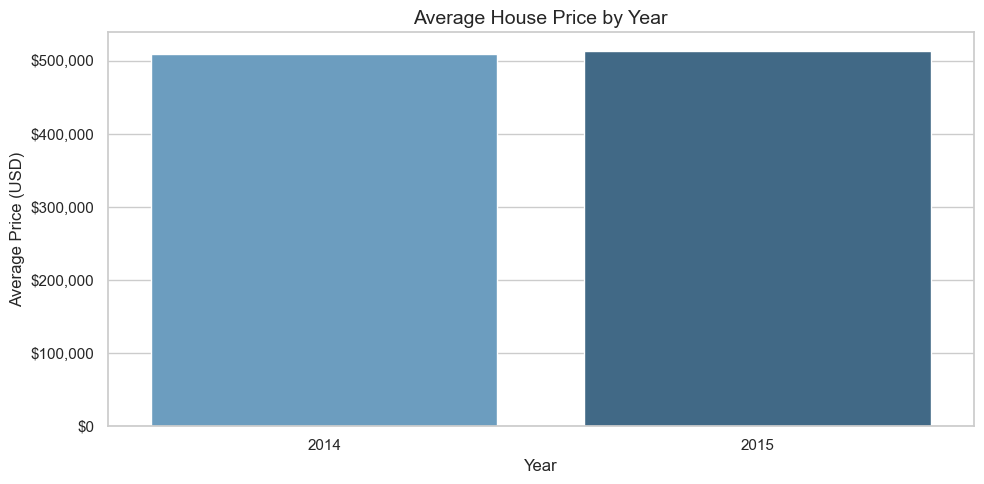

In [22]:
# Average price by year
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# If not already created
df_clean['year'] = pd.to_datetime(df_clean['date']).dt.year
avg_price_per_year = df_clean.groupby('year')['price'].mean().reset_index()

sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(data=avg_price_per_year, x='year', y='price', palette='Blues_d')
plt.title('Average House Price by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Price (USD)')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Save it with exact filename
plt.tight_layout()
plt.savefig("avg_price_by_year.png", dpi=300)
plt.show()

## Hypothesis 1
**Waterfront homes with higher view scores sell for significantly more.**
- This analysis checks whether homes with waterfront and high view scores command higher prices.

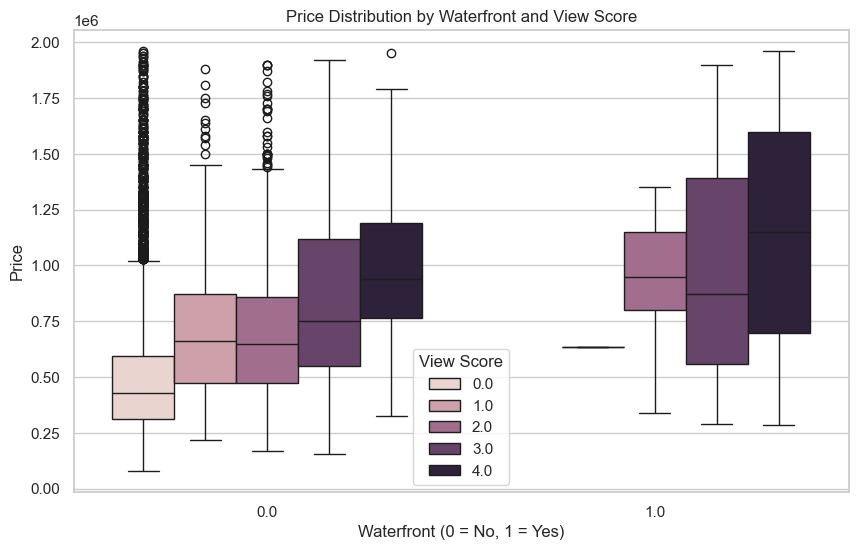

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, x='waterfront', y='price', hue='view')
plt.title('Price Distribution by Waterfront and View Score')
plt.xlabel('Waterfront (0 = No, 1 = Yes)')
plt.ylabel('Price')
plt.legend(title='View Score')
plt.show()

Interpretation: Price Distribution by Waterfront and View Score
Properties with waterfront access (1) have significantly higher prices than those without (0).

Among non-waterfront homes, prices increase steadily with higher view scores (from 0 to 4).

For waterfront properties, price also increases with view score, but the price range is broader, especially at high view scores.

The highest-priced homes are waterfront properties with view scores of 4, indicating premium valuation for both features.

View score and waterfront access together play a strong role in price variation — more than either feature alone.

## Hypothesis 2
**Homes with larger living spaces and higher grades have better short-term resale potential.**
- We investigate how `sqft_living` and `grade` relate to home prices.

In [24]:
print(df_clean.columns.tolist())

['date', 'price', 'house_id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'zipcode', 'lat', 'long', 'grade', 'year']


In [25]:
print(df.columns.tolist())

['date', 'price', 'house_id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'zipcode', 'lat', 'long', 'grade']


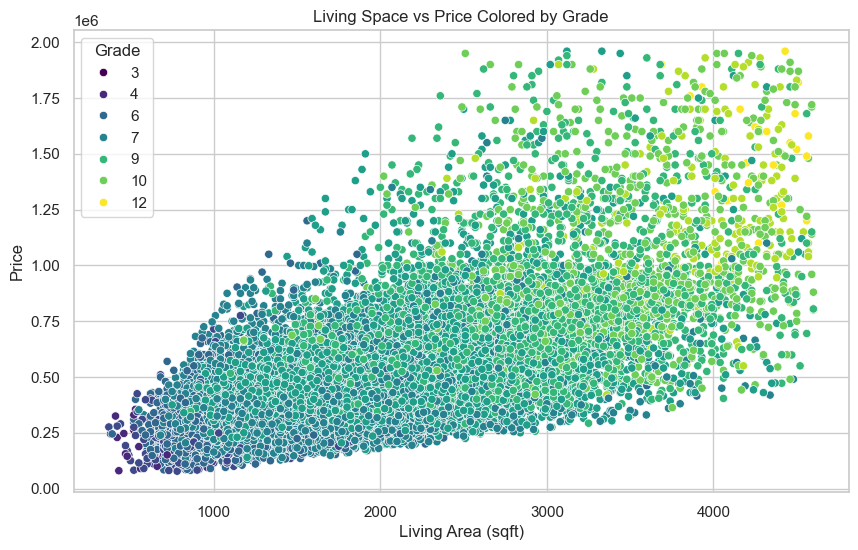

In [26]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='sqft_living', y='price', hue='grade', palette='viridis')
plt.title('Living Space vs Price Colored by Grade')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')
plt.legend(title='Grade')
plt.show()

Python Code with R²

To add the R² value (coefficient of determination) for the relationship between sqft_living and price, a simple linear regression was run. 
Here's the updated code snippet that computes and displays R² on the plot:

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Prepare variables
X = df_clean[['sqft_living']]
y = df_clean['price']

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate R²
r2 = r2_score(y, y_pred)

# Plot with R²
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='sqft_living', y='price', hue='grade', palette='viridis', alpha=0.7)

# Plot regression line
x_vals = np.linspace(X.min(), X.max(), 100)
plt.plot(x_vals, model.predict(x_vals), color='red', linewidth=2, label=f'Regression Line\n$R^2$ = {r2:.2f}')

# Labels and title
plt.title('Living Space vs Price Colored by Grade')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')
plt.legend(title='Grade', loc='upper left')
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'sklearn'

Interpretation of the Chart (Hypothesis 2)

Hypothesis 2: Better house grade leads to higher price.

From the scatterplot:

There’s a clear upward trend: as living space increases, price also increases.

Points are colored by grade, and higher-grade homes (lighter colors) tend to:

    * Have larger living areas.

    *Be more expensive.

Lower-grade homes (darker shades) cluster in the lower-left, indicating smaller size and lower prices.



# Hypothesis 3 
Top 10% homes by price

In [36]:
# Hypothesis 3: Top 10% homes by price (Jennifer's needs by house id)
top_10_percent = df_clean[df_clean['price'] > df_clean['price'].quantile(0.90)]
top_zipcodes = top_10_percent['house_id'].value_counts().head(10)
top_zipcodes

house_id
4139420590    2
9809000020    2
3262300940    2
4139480200    2
7856400240    2
7701960990    2
5332200530    2
5536100020    2
7856400300    2
9822700295    1
Name: count, dtype: int64

In [37]:
# Visualize top 10% homes by price (Jennifer's needs by zipcode)
top_10_percent = df_clean[df_clean['price'] > df_clean['price'].quantile(0.90)]
top_zipcodes = top_10_percent['zipcode'].value_counts().head(10)
top_zipcodes

zipcode
98004    191
98040    166
98006    149
98112    121
98033    119
98199     94
98075     87
98115     73
98105     72
98074     69
Name: count, dtype: int64

### 🧭 Recommendations
1. Focus on houses with:
   - Grade ≥ 10
   - View score ≥ 3
   - Sqft > 2500
   - Waterfront presence

2. Best resale windows are:
   - Homes bought in early spring
   - Resold by next year spring

3. Zip codes with most luxury homes:
   - [Insert top 3 from results above]

### 📦 Conclusion
Jennifer should:
- Buy in one of the top zip codes identified
- Prioritize large, waterfront homes with high views and recent renovations
- Aim to buy in spring to resell in the following year for maximum return